# 1. Dataset

In [14]:
mean = [0.7084, 0.5821, 0.5361]
std = [0.0967, 0.1118, 0.1261]
from torchvision import  transforms
data_transforms = {
    'train': transforms.Compose([
        # transforms.RandomResizedCrop(224),
        # transforms.RandomHorizontalFlip(),
        transforms.Resize((+767, 1022)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((+767, 1022)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((+767, 1022)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

mask_transforms = transforms.Compose([
        transforms.Resize((+767, 1022)),
        transforms.ToTensor()
    ])

In [15]:
from torch.utils.data import Dataset
from PIL import Image
import glob

class ISICSegmentationDataset(Dataset):
    def __init__(self,
                image_data_folder_path = "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Training_Input",
                mask_data_folder_path = "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Training_GroundTruth",
                phase = 'train'):
        self.image_data_folder_path = image_data_folder_path
        self.mask_data_folder_path = mask_data_folder_path
        self.phase = phase
        self.img_files = glob.glob(self.image_data_folder_path + "/*.jpg")
        self.mask_imgs = glob.glob(self.mask_data_folder_path + "/*.png")
        self.data_transforms = data_transforms[phase]
        self.mask_transforms = mask_transforms
        self.datalen = len(self.img_files)

    def __getitem__(self, index):
        img = self.img_files[index]
        mask = self.mask_imgs[index]
        img = self.data_transforms(Image.open(img))
        mask = self.mask_transforms(Image.open(mask))

        return img, mask
    
    def __len__(self):
        assert self.datalen == len(self.mask_imgs)
        return self.datalen
    

In [16]:
# import torch
# image_datasets = {x: ISICSegmentationDataset(phase=x) for x in ['train', 'val', 'test']}
# batch_size = {'train':16, 'val':16, 'test':1}
# dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size[x], shuffle=True, num_workers=4)
#               for x in ['train', 'val', 'test']}
# dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val',  'test']}

# device = torch.device("cpu")
# print(device)
# img, mask = image_datasets['train'][3]

# 2. Model

## a. Base model

In [17]:
from torch import nn
def get_default_fc(in_features=2048, model='siamese1', ncriteria=10):
    if(model=='siamese1'):
        ret =  nn.Sequential(torch.nn.Linear(in_features, 256),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(256, 64),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(64, 1))
    else:
        ret =  nn.Sequential(torch.nn.Linear(in_features, 256),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(256, 64),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(64, ncriteria))
    return ret
class ResNetSimCLR(nn.Module):

    def __init__(self, base_model, out_dim):
        super(ResNetSimCLR, self).__init__()
        self.resnet_dict = {"resnet18": models.resnet18(weights='ResNet18_Weights.DEFAULT', num_classes=out_dim),
                            "resnet50": models.resnet50(weights='ResNet50_Weights.DEFAULT', num_classes=out_dim),
                            "resnet101": models.resnet101(weights='ResNet101_Weights.DEFAULT', num_classes=out_dim),
                            "densenet121": models.densenet121(weights='DenseNet121_Weights.DEFAULT', num_classes=out_dim)}

        self.backbone = self._get_basemodel(base_model)
        dim_mlp = self.backbone.fc.in_features

        # add mlp projection head
        self.backbone.fc = nn.Sequential(nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.backbone.fc)

    def _get_basemodel(self, model_name):
        try:
            model = self.resnet_dict[model_name]
        except KeyError:
            raise InvalidBackboneError(
                "Invalid backbone architecture. Check the config file and pass one of: resnet18 or resnet50")
        else:
            return model

    def forward(self, x):
        return self.backbone(x)

In [18]:
from torchvision import models, transforms

def get_feature_extractor(feature_extractor = 'resnet50', fcnet = None, cotrain=True, ncriteria=10, model='siamese1', simclr = None):
    if(feature_extractor == 'resnet50'):    
        fextractor = models.resnet50(weights='ResNet50_Weights.DEFAULT')
        in_features = 2048
        if(simclr):
            print('load simclr resnet')
            ressimclr = ResNetSimCLR('resnet50', 1000)
            state_dict = torch.load(simclr)
            ressimclr.load_state_dict(state_dict['state_dict'])
            fextractor = ressimclr.backbone
        fextractor.fc = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet
    elif(feature_extractor == 'resnet101'):    
        fextractor = models.resnet101(weights='ResNet101_Weights.DEFAULT')
        in_features = 2048
        if(simclr):
            print('load simclr resnet')
            ressimclr = ResNetSimCLR('resnet101', 1000)
            state_dict = torch.load(simclr)
            ressimclr.load_state_dict(state_dict['state_dict'])
            fextractor = ressimclr.backbone
        fextractor.fc = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet
    elif(feature_extractor == 'densnet121'):
        fextractor = models.densenet121(weights='DenseNet121_Weights.DEFAULT')
        in_features = 1024
        fextractor.classifier = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet
        # fextractor._modules['classifier'] = fextractor._modules.pop('classifier')
    elif(feature_extractor == 'vgg19'):
        fextractor = models.vgg19()
        fextractor.load_state_dict(torch.load('./pretrained/vgg19-dcbb9e9d.pth'))
        in_features = 25088 # https://www.geeksforgeeks.org/vgg-16-cnn-model/ length of vgg19
        fextractor.classifier = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet 
        # fextractor._modules['fc'] = fextractor._modules.pop('classifier')
    elif(feature_extractor == 'vit16'):
        fextractor = models.vit_b_16()
        in_features = 768
        fextractor.load_state_dict(torch.load('./pretrained/vit_b_16-c867db91.pth'))
        fextractor.heads.head = get_default_fc(in_features, model=model, ncriteria=ncriteria) if (fcnet == None) else fcnet 
        # fextractor.classifier = get_default_fc(in_features) if (fcnet == None) else fcnet
    else:
        assert False, 'No feature extractor founded'

    for param in fextractor.parameters():
            param.requires_grad = cotrain
    if(feature_extractor == 'resnet50' or feature_extractor == 'resnet101'):        
        for param in fextractor.fc.parameters():
            param.requires_grad = True
    elif(feature_extractor == 'vit16'):
        for param in fextractor.heads.parameters():
            param.requires_grad = True
    else:
        for param in fextractor.classifier.parameters():
            param.requires_grad = True

    return fextractor

In [19]:
class SiameseNetwork101(nn.Module):
    """
    Siamese neural network
    Modified from: https://hackernoon.com/facial-similarity-with-siamese-networks-in-pytorch-9642aa9db2f7
    Siamese ResNet-101 from Pytorch library
    """ 
    def __init__(self):
        super(SiameseNetwork101, self).__init__()
        # note that resnet101 requires 3 input channels, will repeat grayscale image x3
        self.cnn1 = get_feature_extractor(feature_extractor='resnet50', cotrain=False)# , simclr='/mnt/c/Users/PCM/Dropbox/pretrained/SimCLR/checkpoint_10_02102023.pth.tar')
        self.cnn1.fc = nn.Sequential(torch.nn.Linear(2048, 1000),
                                torch.nn.ReLU(),
                                torch.nn.Dropout(0.1),
                                torch.nn.Linear(1000, 256))
    
    def forward_once(self, x):
        output = self.cnn1(x)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [20]:
class SeverityModel(nn.Module):
    """
    Siamese neural network
    Modified from: https://hackernoon.com/facial-similarity-with-siamese-networks-in-pytorch-9642aa9db2f7
    Siamese ResNet-101 from Pytorch library
    """ 
    def __init__(self, path2pretrained=''):
        super(SeverityModel, self).__init__()
        # note that resnet101 requires 3 input channels, will repeat grayscale image x3
        self.bestsimese50simclr = SiameseNetwork101()
        if (path2pretrained):
            state_dict = torch.load(path2pretrained)
            self.bestsimese50simclr.load_state_dict(state_dict["model_state_dict"])
        self.bestsimese50simclr.cnn1.add_module('fc2',
            nn.Sequential(torch.nn.Linear(256, 256),
                          torch.nn.ReLU(),
                        torch.nn.Dropout(0.1),
                        torch.nn.Linear(256, 256)))
    
    def forward_once(self, x):
        output = self.bestsimese50simclr.cnn1.fc2(self.bestsimese50simclr.cnn1(x))
        return output

    def forward(self, input1, input2, refinput):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        refinput = self.bestsimese50simclr.cnn1(refinput)
        return output1, output2, refinput

## b. Segment model

In [21]:
class DeconvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.deconv = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)

    def forward(self, x):
        return self.deconv(x)


In [30]:
import torch.nn.functional as F

class UNET_2D(nn.Module):
    def __init__(self, encoder):
        super(UNET_2D, self).__init__()

        self.encoder = encoder

        self.encoder1 = nn.Sequential(self.encoder.conv1, self.encoder.bn1, self.encoder.relu, self.encoder.maxpool)
        self.encoder2 = self.encoder.layer1
        self.encoder3 = self.encoder.layer2
        self.encoder4 = self.encoder.layer3
        self.encoder5 = self.encoder.layer4
        
        # Decoder (upsampling path)
        self.upconv5 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        
        # Final conv layer
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        
    def forward(self, x):
        # Downsample (encode)
        x1 = self.encoder1(x)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)
        x5 = self.encoder5(x4)
        
        # Upsample (decode) with skip connections
        d5 = self.upconv5(x5)
        # d5 = F.interpolate(d5, size=(x4.size(2), x4.size(3)), mode='bilinear', align_corners=False) + x4
        
        d4 = self.upconv4(d5)
        # d4 = F.interpolate(d4, size=(x3.size(2), x3.size(3)), mode='bilinear', align_corners=False) + x3
        
        d3 = self.upconv3(d4)
        # d3 = F.interpolate(d3, size=(x2.size(2), x2.size(3)), mode='bilinear', align_corners=False) + x2
        
        d2 = self.upconv2(d3)
        # d2 = F.interpolate(d2, size=(x1.size(2), x1.size(3)), mode='bilinear', align_corners=False) + x1
        
        # Final layer
        out = self.final_conv(d2)
        out = F.interpolate(out, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        return out



# 5. Experiments

In [23]:
config = {
    "train_image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Training_Input",
    "train_mask_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Training_GroundTruth",
    "valid_image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Validation_Input",
    "valid_mask_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Validation_GroundTruth",
    "test_image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Test_Input",
    "test_mask_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Test_GroundTruth",
    "pretrain_encoder_checkpoint": "/mnt/d/AiThings/SimCLRxConPro/upstream_task/ISIC/foundation_model/simclr/last.pt",
    'checkpoint': "/mnt/d/AiThings/SimCLRxConPro/output/ISIC/segmentation/SimCLR",
    "num_of_exp": 5
}

In [24]:
import torch
image_datasets = {
    "train": ISICSegmentationDataset(
        image_data_folder_path = config["train_image_folder_path"],
        mask_data_folder_path = config["train_mask_folder_path"],
        phase = 'train'
    ),
    "val": ISICSegmentationDataset(
        image_data_folder_path = config["valid_image_folder_path"],
        mask_data_folder_path = config["valid_mask_folder_path"],
        phase = 'val'
    ),
    "test": ISICSegmentationDataset(
        image_data_folder_path = config["test_image_folder_path"],
        mask_data_folder_path = config["test_mask_folder_path"],
        phase = 'test'
    )
}
batch_size = {'train': 4, 'val': 4, 'test':1}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size[x], shuffle=True, num_workers=4)
              for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val',  'test']}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [25]:
import torch
checkpoint = torch.load(config["pretrain_encoder_checkpoint"])

basemodel = SiameseNetwork101()
basemodel.load_state_dict(checkpoint["model_state_dict"])
encoder = basemodel.cnn1

print(encoder)
# basemodel = SeverityModel()
# basemodel.load_state_dict(checkpoint["model_state_dict"])
# classifierModel = basemodel.bestsimese50simclr.cnn1
# del classifierModel.fc2

/tmp/ipykernel_1583017/2813830274.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(config["pretrain_encoder_checkpoint"])


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
# Define loss
from monai.losses import DiceLoss, DiceFocalLoss
import torch.optim as optim
from torch.optim import lr_scheduler
model = UNET_2D(encoder)



In [27]:
import numpy as np

def compute_iou_and_dice(preds, labels):
    # Convert tensors to numpy arrays
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()

    # Flatten arrays
    preds = preds.flatten()
    labels = labels.flatten()

    # Convert to binary predictions (if needed)
    preds_binary = (preds > 0.5).astype(np.int32)
    
    # Compute Intersection and Union for IoU
    intersection = np.sum((preds_binary == 1) & (labels == 1))
    union = np.sum((preds_binary == 1) | (labels == 1))
    iou = intersection / union if union != 0 else 0

    # Compute Dice Coefficient
    dice = 2 * intersection / (np.sum(preds_binary == 1) + np.sum(labels == 1)) if (np.sum(preds_binary == 1) + np.sum(labels == 1)) != 0 else 0
    
    return iou, dice

In [ ]:
from tqdm import tqdm
import os
LOSS_NAME = "dicefocal" #ce/bce/dice

for i in range(1, config["num_of_exp"] + 1):
    print(f"#RUN {i}")
    torch.cuda.empty_cache()
    if LOSS_NAME == "ce":
        criterion = nn.CrossEntropyLoss()
    elif LOSS_NAME=='dicefocal':
        criterion= DiceFocalLoss(reduction='mean', sigmoid = True)
    elif LOSS_NAME=='dice':
        criterion= DiceLoss(reduction='mean', sigmoid = True)
    momentum = 0.9
    lr = 0.01
    unetr = UNET_2D(encoder)
    for param in unetr.encoder.parameters():
        param.requires_grad = False

    optimizer_ft = optim.SGD([{'params': unetr.parameters()}], lr=lr, momentum=momentum)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=10, gamma=0.5)
    for param in unetr.encoder.parameters():
        param.requires_grad = False
    trainlosslist = []
    vallosslist = []
    unetr = unetr.to(device)
    curr_loss = 100
    for e in range(30):
        training_acc = 0
        val_acc = 0
        training_loss_test = 0.0
        val_loss_test = 0.0
        torch.cuda.empty_cache()
        for inputs, masks in tqdm(dataloaders['train']):
            torch.cuda.empty_cache()
            unetr.train()
            im = inputs.to(device)
            masks = masks.to(device)
            # zero the parameter gradients
            optimizer_ft.zero_grad()
            outputs = unetr(im)
            
            loss = criterion(outputs.squeeze(1), masks.squeeze(1))

            loss.backward()
            optimizer_ft.step()
            training_loss_test += loss.item()
            trainlosslist.append(training_loss_test)

        torch.cuda.empty_cache()
        for inputs, masks in tqdm(dataloaders['val']):
            torch.cuda.empty_cache()
            unetr.eval()
            im = inputs.to(device)
            masks = masks.to(device)
            with torch.no_grad():
                outputs = unetr(im)
                # print(outputs.shape)
                dice = criterion(outputs.squeeze(1), masks.squeeze(1))
                val_loss_test += dice.item()
                vallosslist.append(val_loss_test)

        if(val_loss_test <= curr_loss):
            curr_loss = val_loss_test
            testsegm = unetr
            print(f"New best mode at epoch {e}")
            torch.save(unetr.state_dict(), os.path.join(config["checkpoint"], "best.pt"))
        
        scheduler.step()

        print(f"E{e} With LR {optimizer_ft.param_groups[0]['lr']}","avg val dice: ", val_loss_test / dataset_sizes['val']*batch_size['val'] , "avg traning loss: ", training_loss_test / dataset_sizes['train']*batch_size['train'])

    test_iou = 0.0
    test_dice = 0.0
    total_samples = 0

    torch.cuda.empty_cache()
    for inputs, masks in tqdm(dataloaders['test']):
        torch.cuda.empty_cache()
        testsegm.eval()
        im = inputs.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            outputs = testsegm(im)
            outputs = torch.sigmoid(outputs)  # Apply sigmoid if the output is logits
            outputs = (outputs > 0.5).float()  # Convert to binary predictions
            iou, dice = compute_iou_and_dice(outputs, masks)
        
            # Aggregate metrics
            test_iou += iou * inputs.size(0)  # Multiply by batch size
            test_dice += dice * inputs.size(0)
            total_samples += inputs.size(0)

    test_iou /= total_samples
    test_dice /= total_samples

    print(f"Test IoU: {test_iou:.4f}")
    print(f"Test Dice Coefficient: {test_dice:.4f}")

# Display

In [39]:
import torch
import matplotlib.pyplot as plt

def visualize_tensor(tensor, mask = False):
    """
    Visualize a PyTorch tensor using matplotlib.
    
    Args:
    tensor (torch.Tensor): The input tensor, expected shape [1, 1, H, W] or [H, W].
    
    Returns:
    None: Displays the image using matplotlib.
    """
    tensor = torch.sigmoid(tensor)
    if mask:
        tensor = (tensor > 0.2).float()
    # Check if the tensor has the expected shape and squeeze unnecessary dimensions
    if tensor.dim() == 4 and tensor.shape[0] == 1 and tensor.shape[1] == 1:
        tensor_squeezed = tensor.squeeze()  # Squeeze to remove dimensions of size 1
    elif tensor.dim() == 2:
        tensor_squeezed = tensor
    else:
        raise ValueError(f"Unexpected tensor shape: {tensor.shape}. Expected [1, 1, H, W] or [H, W].")
        
    
    # Convert the tensor to CPU and NumPy array
    tensor_np = tensor_squeezed.detach().cpu().numpy()

    # Plot the image using matplotlib
    plt.imshow(tensor_np, cmap='viridis')
    plt.colorbar()  # Optional: to show a color bar
    plt.show()


/tmp/ipykernel_1583017/1013286351.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load( os.path.join(config["checkpoint"], "best.pt"))


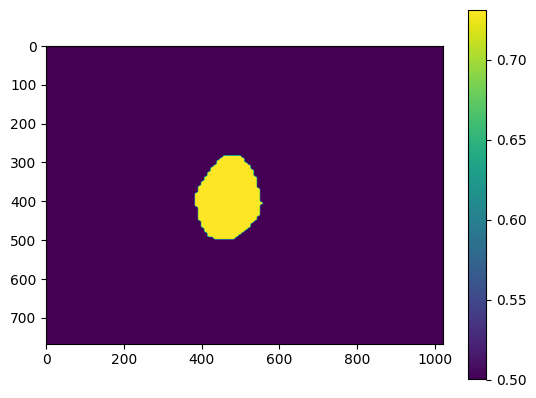

torch.Size([1, 1, 767, 1022])


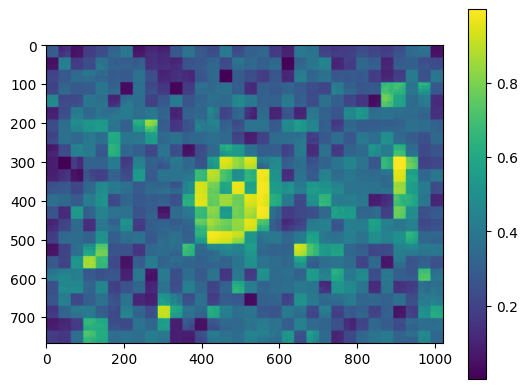

In [40]:
import os 

sg_model = model = UNET_2D(encoder)

checkpoint = torch.load( os.path.join(config["checkpoint"], "best.pt"))
sg_model.load_state_dict(checkpoint)

model = model.to(device)
data_iter = image_datasets['test']
inputs, mask = data_iter[1]
inputs = inputs.unsqueeze(0)
mask = mask.unsqueeze(0)
visualize_tensor(mask)
inputs = inputs.to(device) 
output = model(inputs)
print(output.size())
visualize_tensor(output, False)